<a href="https://colab.research.google.com/github/nicholas-schwier-class/Computational-Probability-and-Stats-2026/blob/main/Ch3_A_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Random Variables
Concept

A random variable assigns a number to each outcome of a random experiment.

CS Example:

  Let:
  X = number of failed login attempts before a successful login

In [21]:
import numpy as np

# Simulate one user session
# 0 = success, 1 = failure
# Suppose probability of success = 0.7
p_success = 0.7

attempts = 0
while True:
    result = np.random.choice([0, 1], p=[p_success, 1 - p_success])
    attempts += 1
    if result == 0:
        break

print("Number of login attempts:", attempts)


Number of login attempts: 1


## Probability Mass Function (PMF)
Concept

The PMF gives:
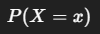

CS Example:

Suppose a packet transmission succeeds with probability 0.8.
Let X = 1 if success, 0 if failure.

In [1]:
from scipy.stats import bernoulli

p = 0.8

# PMF values
print("P(X=0) =", bernoulli.pmf(0, p))
print("P(X=1) =", bernoulli.pmf(1, p))


P(X=0) = 0.2
P(X=1) = 0.8


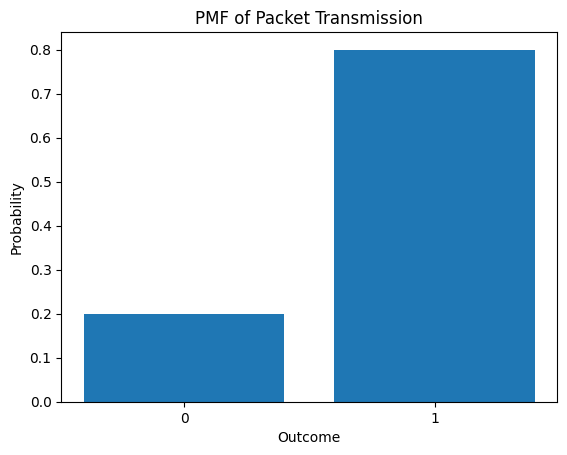

In [3]:
import matplotlib.pyplot as plt

x = [0, 1]
pmf = [bernoulli.pmf(0, p), bernoulli.pmf(1, p)]

plt.bar(x, pmf)
plt.xticks([0,1])
plt.title("PMF of Packet Transmission")
plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.show()


## Independent Random Variables
Concept

Two random variables are independent if:
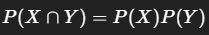

CS Example:

Two servers fail independently.

In [4]:
p_server1 = 0.1
p_server2 = 0.2

# Probability both fail
p_both = p_server1 * p_server2

print("P(Server1 fails AND Server2 fails) =", p_both)


P(Server1 fails AND Server2 fails) = 0.020000000000000004


In [5]:
N = 100000

server1 = np.random.rand(N) < p_server1
server2 = np.random.rand(N) < p_server2

both_fail = np.mean(server1 & server2)

print("Simulated probability both fail:", both_fail)
print("Theoretical probability:", p_server1 * p_server2)


Simulated probability both fail: 0.01954
Theoretical probability: 0.020000000000000004


## Bernoulli Distribution
Concept

A Bernoulli random variable models a single yes/no experiment.

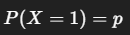

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli

p_compile = 0.85
n_trials = 1000  # simulate 1000 builds

# Generate Bernoulli samples
build_results = bernoulli.rvs(p_compile, size=n_trials)

print("First 20 build results:", build_results[:20])


First 20 build results: [1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1 0 1 1]


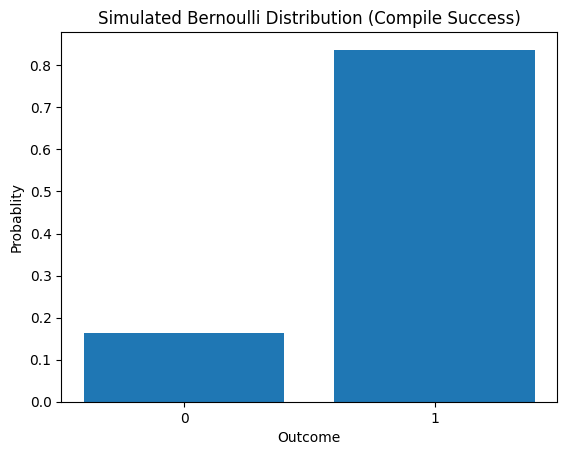

In [26]:
# Count occurrences
num_failures = np.sum(build_results == 0)
num_successes = np.sum(build_results == 1)

# Convert to proportions
fail_rate = num_failures / n_trials
success_rate = num_successes / n_trials

# Plot
plt.bar([0, 1], [fail_rate, success_rate])
plt.xticks([0, 1])
plt.xlabel("Outcome")
plt.ylabel("Probablity")
plt.title("Simulated Bernoulli Distribution (Compile Success)")
plt.show()


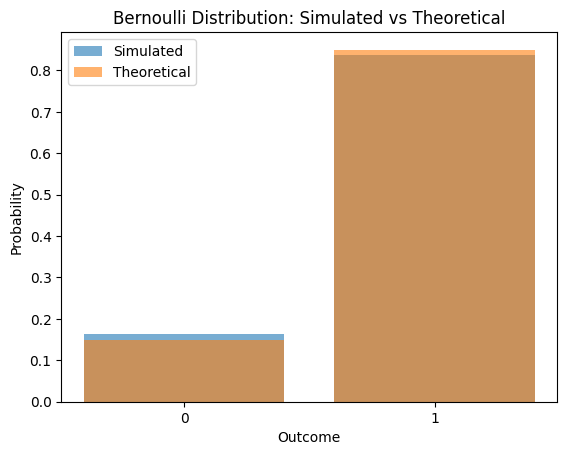

In [25]:
x = [0, 1]

plt.bar(x, [fail_rate, success_rate], alpha=0.6, label="Simulated")
plt.bar(x, theoretical, alpha=0.6, label="Theoretical")

plt.xticks([0, 1])
plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.title("Bernoulli Distribution: Simulated vs Theoretical")
plt.legend()
plt.show()


## Geometric Distribution
Concept

Models number of trials until first success.

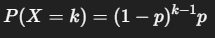



In [8]:
#Number of retries until a database query succeeds.
from scipy.stats import geom

p_success = 0.6

# Simulate 10 experiments
retries = geom.rvs(p_success, size=10)
print("Retries until success:", retries)


Retries until success: [2 1 1 1 2 1 1 1 1 3]


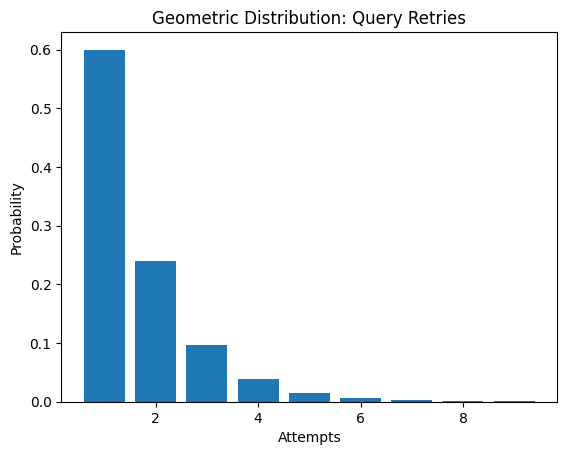

In [9]:
x = np.arange(1, 10)
pmf = geom.pmf(x, p_success)

plt.bar(x, pmf)
plt.title("Geometric Distribution: Query Retries")
plt.xlabel("Attempts")
plt.ylabel("Probability")
plt.show()


## Binomial Distribution
Concept

Number of successes in n independent Bernoulli trials.

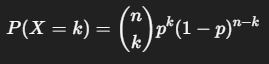

In [10]:
#Out of 20 API calls, how many succeed?

from scipy.stats import binom

n = 20
p = 0.9

# Probability exactly 18 successes
print("P(18 successes) =", binom.pmf(18, n, p))


P(18 successes) = 0.28517980706429835


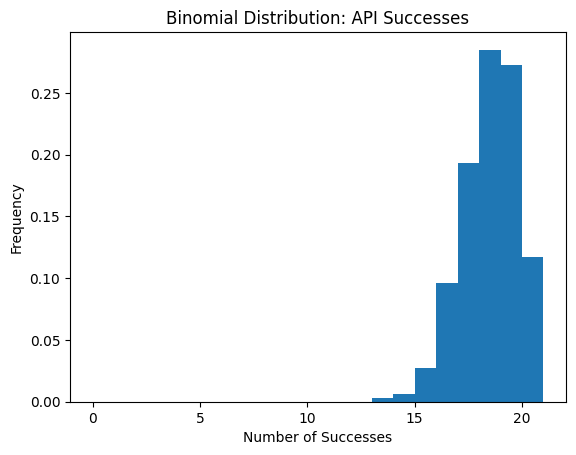

In [11]:
results = binom.rvs(n, p, size=1000)

plt.hist(results, bins=range(n+2), density=True)
plt.title("Binomial Distribution: API Successes")
plt.xlabel("Number of Successes")
plt.ylabel("Frequency")
plt.show()


Negative Binomial Distribution
Concept

Number of trials required to achieve r successes.
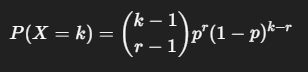

In [12]:
#How many attempts are needed to successfully crack 3 passwords (assuming success probability p per attempt)?

from scipy.stats import nbinom

r = 3      # number of successes
p = 0.4    # probability of success

# Simulate 10 experiments
attempts = nbinom.rvs(r, p, size=10)
print("Trials needed to get 3 successes:", attempts)


Trials needed to get 3 successes: [ 3  3  3  1  2  7  3  2 12  3]


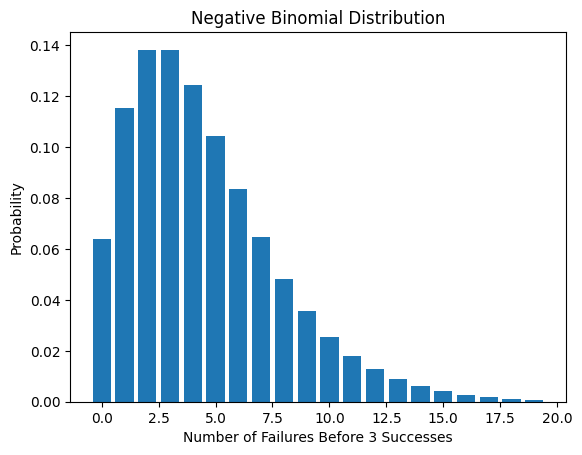

In [13]:
x = np.arange(0, 20)
pmf = nbinom.pmf(x, r, p)

plt.bar(x, pmf)
plt.title("Negative Binomial Distribution")
plt.xlabel("Number of Failures Before 3 Successes")
plt.ylabel("Probability")
plt.show()
